<h1>Set operations with overlay</h1>

<p>When working with multiple spatial datasets – especially multiple <em>polygon</em> or <em>line</em> datasets – users often wish to create new shapes based on places where those datasets overlap (or don’t overlap). These manipulations are often referred using the language of sets – intersections, unions, and differences. These types of operations are made available in the GeoPandas library through the
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> method.</p>

<p>The basic idea is demonstrated by the graphic below but keep in mind that overlays operate at the DataFrame level, not on individual geometries, and the properties from both are retained. In effect, for every shape in the left
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html" title="geopandas.GeoDataFrame"><code>GeoDataFrame</code></a>, this operation is executed against every other shape in the right
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html" title="geopandas.GeoDataFrame"><code>GeoDataFrame</code></a>:</p>

<img src="https://geopandas.org/en/stable/_images/overlay_operations.png">

<p><strong>Source: QGIS documentation</strong></p>

<div class="alert alert-block alert-info">
<p>Note</p>
<p>Note to users familiar with the <em>shapely</em> library: <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> can be thought of as offering versions of the standard <em>shapely</em> set operations that deal with the complexities of applying set operations to two <em>GeoSeries</em>. The standard <em>shapely</em> set operations are also available as
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.html" title="geopandas.GeoSeries"><code>GeoSeries</code></a> methods.</p>
</div>

# <h2>The different overlay operations</h2>

<p>First, create some example data:</p>

In [16]:
import geopandas
from shapely.geometry import Polygon

In [17]:
polys1 = geopandas.GeoSeries([Polygon([(0,0), (2,0), (2,2), (0,2)]), Polygon([(2,2), (4,2), (4,4), (2,4)])])
polys2 = geopandas.GeoSeries([Polygon([(1,1), (3,1), (3,3), (1,3)]), Polygon([(3,3), (5,3), (5,5), (3,5)])])

In [18]:
df1 = geopandas.GeoDataFrame(geometry=polys1)
df2 = geopandas.GeoDataFrame(geometry=polys2)

<p>These two GeoDataFrames have some overlapping areas:</p>

<AxesSubplot: >

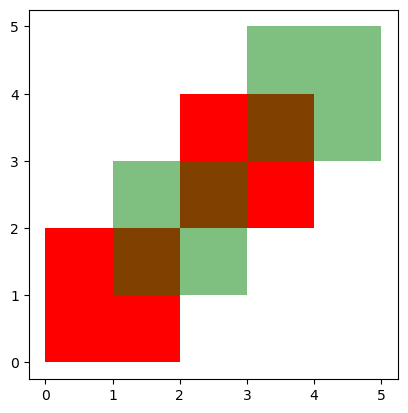

In [19]:
ax = df1.plot(color='red')

df2.plot(ax=ax, color='green', alpha=0.5)

<p>The above example illustrates the different overlay modes.
The <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> method will determine the set of all individual geometries from overlaying the two input GeoDataFrames.
This result covers the area covered by the two input GeoDataFrames, and also preserves all unique regions defined by the combined boundaries of the two GeoDataFrames.</p>

<div class="alert alert-block alert-info">
<p>Note</p>
<p>For historical reasons, the overlay method is also available as a top-level function
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.overlay.html" title="geopandas.overlay"><code>overlay()</code></a>.
It is recommended to use the method as the function may be deprecated in the future.</p>
</div>

<p>When using <code>how='union'</code>, all those possible geometries are returned:</p>

In [20]:
res_union = df1.overlay(df2, how='union')

In [21]:
res_union

,geometry
0,"POLYGON ((2.00000 2.00000, 2.00000 1.00000, 1...."
1,"POLYGON ((2.00000 2.00000, 2.00000 3.00000, 3...."
2,"POLYGON ((4.00000 4.00000, 4.00000 3.00000, 3...."
3,"POLYGON ((2.00000 0.00000, 0.00000 0.00000, 0...."
4,"MULTIPOLYGON (((3.00000 4.00000, 3.00000 3.000..."
5,"MULTIPOLYGON (((2.00000 3.00000, 2.00000 2.000..."
6,"POLYGON ((3.00000 5.00000, 5.00000 5.00000, 5...."


<AxesSubplot: >

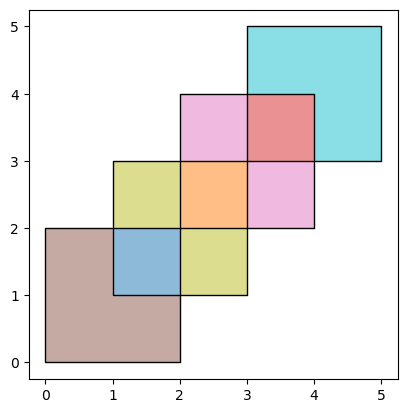

In [38]:
ax = res_union.plot(alpha=0.5, cmap='tab10')

df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')

<p>The other <code>how</code> operations will return different subsets of those geometries.
With <code>how='intersection'</code>, it returns only those geometries that are contained by both GeoDataFrames:</p>

In [23]:
res_intersection = df1.overlay(df2, how='intersection')

In [24]:
res_intersection

,geometry
0,"POLYGON ((2.00000 2.00000, 2.00000 1.00000, 1...."
1,"POLYGON ((2.00000 2.00000, 2.00000 3.00000, 3...."
2,"POLYGON ((4.00000 4.00000, 4.00000 3.00000, 3...."


<AxesSubplot: >

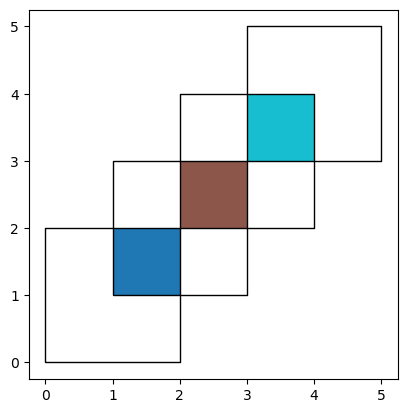

In [25]:
ax = res_intersection.plot(cmap='tab10')

df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')

<p><code>how='symmetric_difference'</code> is the opposite of <code>'intersection'</code> and returns the geometries that are only part of one of the GeoDataFrames but not of both:</p>

In [26]:
res_symdiff = df1.overlay(df2, how='symmetric_difference')

In [27]:
res_symdiff

,geometry
0,"POLYGON ((2.00000 0.00000, 0.00000 0.00000, 0...."
1,"MULTIPOLYGON (((3.00000 4.00000, 3.00000 3.000..."
2,"MULTIPOLYGON (((2.00000 3.00000, 2.00000 2.000..."
3,"POLYGON ((3.00000 5.00000, 5.00000 5.00000, 5...."


<AxesSubplot: >

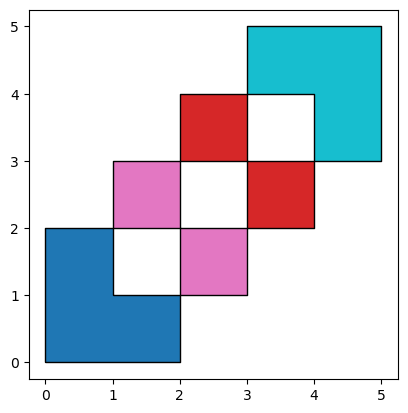

In [28]:
ax = res_symdiff.plot(cmap='tab10')

df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')

<p>To obtain the geometries that are part of <code>df1</code> but are not contained in <code>df2</code>, you can use <code>how='difference'</code>:</p>

In [29]:
res_difference = df1.overlay(df2, how='difference')

In [30]:
res_difference

,geometry
0,"POLYGON ((2.00000 0.00000, 0.00000 0.00000, 0...."
1,"MULTIPOLYGON (((3.00000 4.00000, 3.00000 3.000..."


<AxesSubplot: >

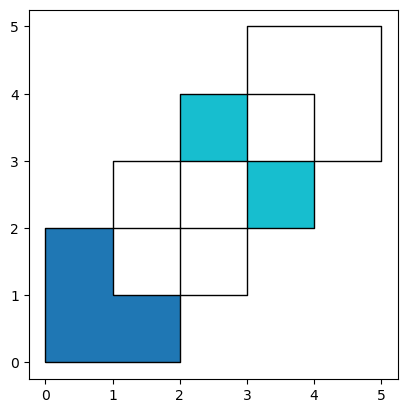

In [31]:
ax = res_difference.plot(cmap='tab10')

df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')

<p>Finally, with <code>how='identity'</code>, the result consists of the surface of <code>df1</code>, but with the geometries obtained from overlaying <code>df1</code> with <code>df2</code>:</p>

In [39]:
res_identity = df1.overlay(df2, how='identity')

In [40]:
res_identity

,geometry
0,"POLYGON ((2.00000 2.00000, 2.00000 1.00000, 1...."
1,"POLYGON ((2.00000 2.00000, 2.00000 3.00000, 3...."
2,"POLYGON ((4.00000 4.00000, 4.00000 3.00000, 3...."
3,"POLYGON ((2.00000 0.00000, 0.00000 0.00000, 0...."
4,"MULTIPOLYGON (((3.00000 4.00000, 3.00000 3.000..."


<AxesSubplot: >

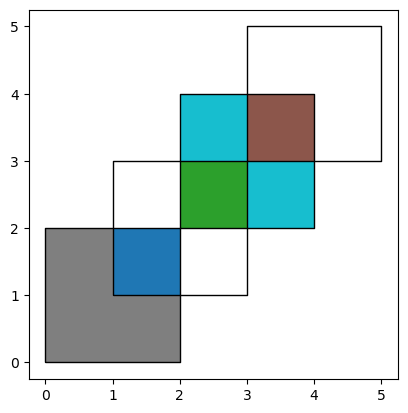

In [41]:
ax = res_identity.plot(cmap='tab10')

df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')

# <h2>Overlay groceries example</h2>

<p>First, load the Chicago community areas and groceries example datasets and select :</p>

In [45]:
import geodatasets

In [46]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_commpop"))
groceries = geopandas.read_file(geodatasets.get_path("geoda.groceries"))

In [47]:
# Project to crs that uses meters as distance measure
chicago = chicago.to_crs("ESRI:102003")
groceries = groceries.to_crs("ESRI:102003")

<p>To illustrate the <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> method, consider the following case in which one wishes to identify the “served” portion of each area – defined as areas within 1km of a grocery store – using a <code>GeoDataFrame</code> of community areas and a <code>GeoDataFrame</code> of groceries.</p>

<AxesSubplot: >

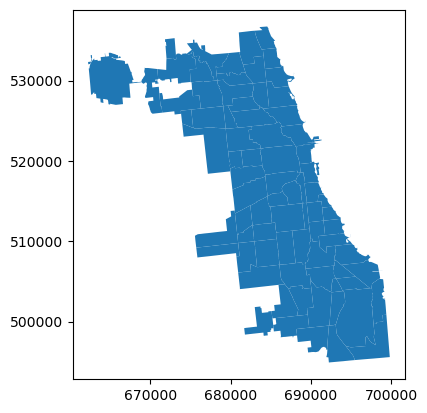

In [48]:
# Look at Chicago:
chicago.plot()

In [49]:
# Now buffer groceries to find area within 1km.
# Check CRS -- USA Contiguous Albers Equal Area, units of meters.
groceries.crs

<Derived Projected CRS: ESRI:102003>
Name: USA_Contiguous_Albers_Equal_Area_Conic
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: USA_Contiguous_Albers_Equal_Area_Conic
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [50]:
# make 1km buffer
groceries['geometry'] = groceries.buffer(1000)

<AxesSubplot: >

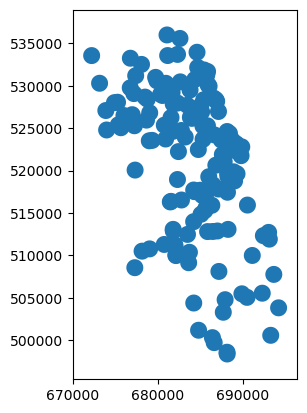

In [51]:
groceries.plot()

<p>To select only the portion of community areas within 1km of a grocery, specify the <code>how</code> option to be “intersect”, which creates a new set of polygons where these two layers overlap:</p>

In [52]:
chicago_cores = chicago.overlay(groceries, how='intersection')

<AxesSubplot: >

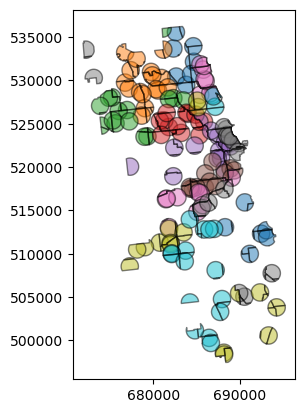

In [53]:
chicago_cores.plot(alpha=0.5, edgecolor='k', cmap='tab10')

<p>Changing the <code>how</code> option allows for different types of overlay operations. For example, if you were interested in the portions of Chicago <em>far</em> from groceries (the peripheries), you would compute the difference of the two.</p>

In [54]:
chicago_peripheries = chicago.overlay(groceries, how='difference')

<AxesSubplot: >

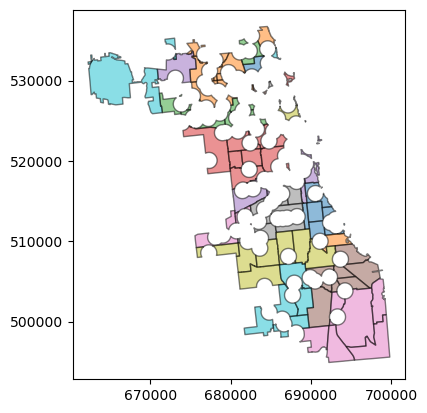

In [55]:
chicago_peripheries.plot(alpha=0.5, edgecolor='k', cmap='tab10')

# <h2>keep_geom_type keyword</h2>

<p>In default settings, <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> returns only geometries of the same geometry type as GeoDataFrame (left one) has, where Polygon and MultiPolygon is considered as a same type (other types likewise).
You can control this behavior using <code>keep_geom_type</code> option, which is set to True by default.
Once set to False, <code>overlay</code> will return all geometry types resulting from selected set-operation.
Different types can result for example from intersection of touching geometries, where two polygons intersects in a line or a point.</p>

# <h2>More examples</h2>

<p>A larger set of examples of the use of <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.overlay.html" title="geopandas.GeoDataFrame.overlay"><code>overlay()</code></a> can be found
<a href="https://nbviewer.jupyter.org/github/geopandas/geopandas/blob/main/doc/source/gallery/overlays.ipynb">here</a></p>